In [297]:
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D
from collections import Counter

In [298]:
#gene_disease_matrix = pd.read_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/analysis/glowmatrix.tsv',sep = '\t') 
gene_disease_matrix = pd.read_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/revision/ToppGenes.tsv',sep = '\t') 
gene_disease_matrix

,SYMBOL,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
0,MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,...,2187.0,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0
1,MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,...,3741.0,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0
2,DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,...,214.0,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0
3,ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,...,272.0,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0
4,TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,...,2436.0,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24209,C7orf43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24210,NEPRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24211,TMEM251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24212,WISP3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [299]:
gene_disease_matrix.shape

(24214, 210)

In [300]:
gene_disease_matrix.shape

(24214, 210)

In [301]:
gene_disease_matrix

,SYMBOL,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
0,MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,...,2187.0,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0
1,MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,...,3741.0,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0
2,DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,...,214.0,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0
3,ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,...,272.0,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0
4,TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,...,2436.0,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24209,C7orf43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24210,NEPRO,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24211,TMEM251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24212,WISP3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Cargamos la matriz del ranking de GLOWgenes con cada panel de panelApp
Obtenemos, de cada panel, su valor más bajo de GLOWgene para darle a los NA ese ranking (para que los NA tengan el valor del último gen rankeado + 1) 

In [302]:
max_valuedisease=gene_disease_matrix.set_index("SYMBOL").max(axis=0)
max_valuedisease.head()

Distal_myopathies_GA                                                                 24080.0
Ductal_plate_malformation_GA                                                         24083.0
Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA    24084.0
Early_onset_dystonia_GA                                                              24042.0
Early_onset_or_syndromic_epilepsy_GA                                                 23371.0
dtype: float64

In [303]:
gene_disease_matrix = gene_disease_matrix.set_index("SYMBOL").fillna(gene_disease_matrix.set_index("SYMBOL").max()+1) # establezco NA como el máximo de su panel.
gene_disease_matrix

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,308.0,...,2187.0,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0
MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,224.0,...,3741.0,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0
DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,79.0,...,214.0,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0
ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,144.0,...,272.0,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0
TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,189.0,...,2436.0,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C7orf43,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24084.0,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0
NEPRO,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24084.0,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0
TMEM251,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24084.0,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0


In [304]:
data_np = gene_disease_matrix.to_numpy(copy=True)

Transformamos el dataframe con los genes y las enfermedades en una matriz de numpy.

# PCA

In [307]:
pca = PCA(n_components=3)  # Reduce to 2 components for visualization purposes
pca.fit(data_np)

# Explained variance
explained_variance = pca.explained_variance_
print("Explained Variance:", explained_variance)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained Variance Ratio:", explained_variance_ratio)
explained_variance = explained_variance_ratio

# PCA components (eigenvectors)
components = pca.components_
#print("PCA Components:\n", components)

# Singular values
singular_values = pca.singular_values_
#print("Singular Values:", singular_values)


reduced_matrix = pca.fit_transform(data_np)

Explained Variance: [7.53853689e+09 4.05420278e+08 2.45333583e+08]
Explained Variance Ratio: [0.73858934 0.03972112 0.0240366 ]


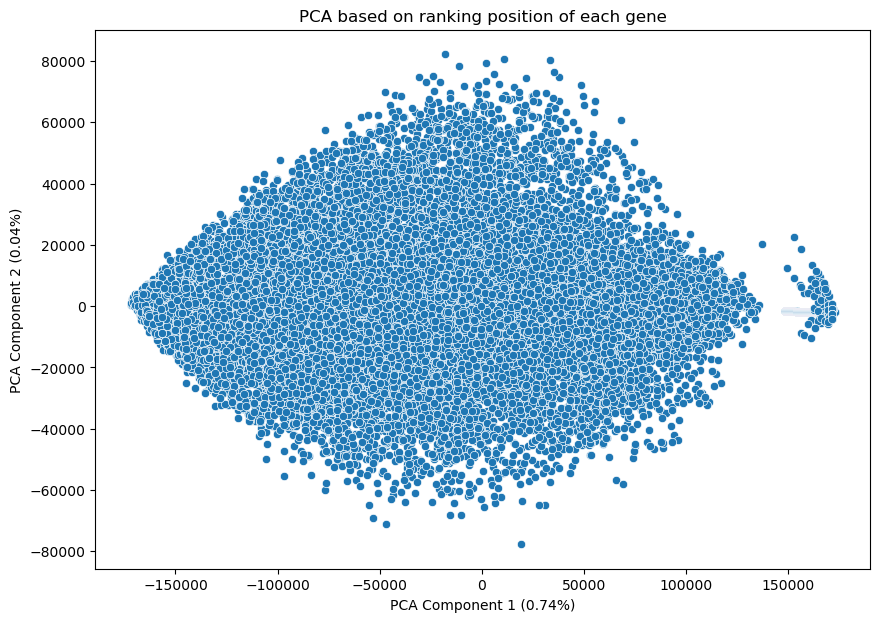

In [308]:
# Visualization
plt.figure(figsize=(10, 7))
fig = sns.scatterplot(x=reduced_matrix[:, 0], y=reduced_matrix[:, 1])
plt.title('PCA based on ranking position of each gene')
plt.xlabel('PCA Component 1 (' + str(round(explained_variance_ratio[0], 2)) +"%)")
plt.ylabel('PCA Component 2 (' + str(round(explained_variance_ratio[1], 2)) +"%)")
#fig.invert_xaxis() 
#fig.invert_yaxis() 
plt.show()

## t-SNE

In [309]:
#https://www.datacamp.com/tutorial/introduction-t-sne
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(data_np)
tsne.kl_divergence_

2.2855782508850098

In [11]:
import numpy as np
'''
#perplexity = np.arange(5, 55, 5)
perplexity = np.arange(100, 120, 5)
divergence = []

for i in perplexity:
    model = TSNE(n_components=2, init="pca", perplexity=i)
    reduced = model.fit_transform(data_np)
    divergence.append(model.kl_divergence_)
fig = px.line(x=perplexity, y=divergence, markers=True)
fig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")
fig.update_traces(line_color="red", line_width=1)
fig.show()
'''

'\n#perplexity = np.arange(5, 55, 5)\nperplexity = np.arange(100, 120, 5)\ndivergence = []\n\nfor i in perplexity:\n    model = TSNE(n_components=2, init="pca", perplexity=i)\n    reduced = model.fit_transform(data_np)\n    divergence.append(model.kl_divergence_)\nfig = px.line(x=perplexity, y=divergence, markers=True)\nfig.update_layout(xaxis_title="Perplexity Values", yaxis_title="Divergence")\nfig.update_traces(line_color="red", line_width=1)\nfig.show()\n'

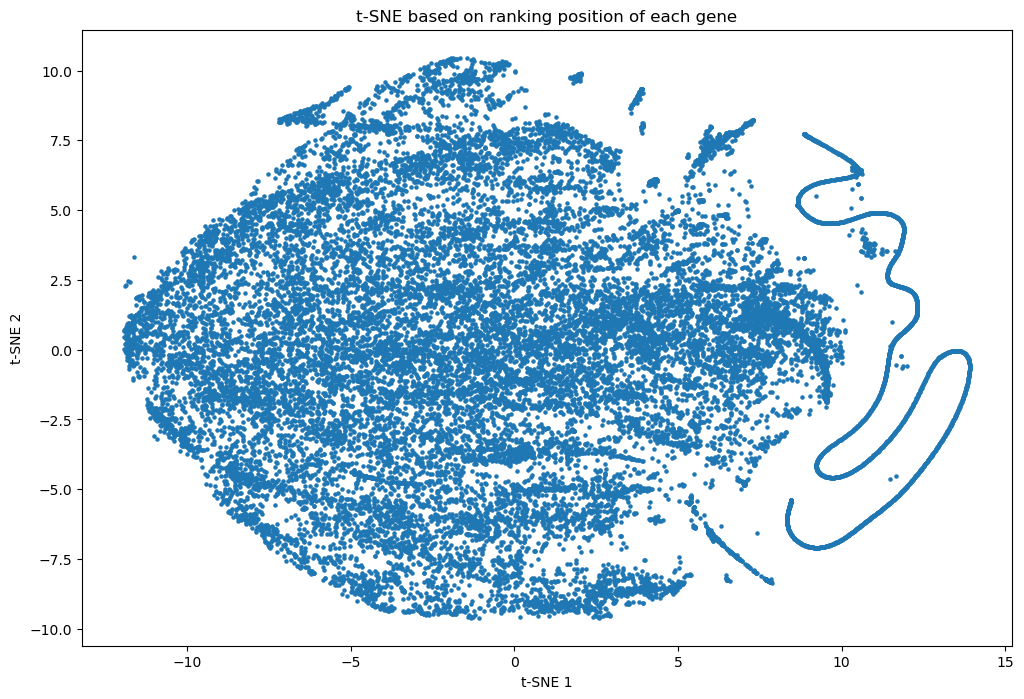

In [310]:
# Fit and transform the data using t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300)
tsne_results = tsne.fit_transform(data_np)

# Plot t-SNE results
plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], s=5)
plt.title('t-SNE based on ranking position of each gene')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [13]:
tsne.kl_divergence_

3.669490337371826

## Clustering (K-Means)

Vamos a hacer el clústering con K-means. Necesitamos saber el número de clusters a utilizar. Usamos el método del codo. 

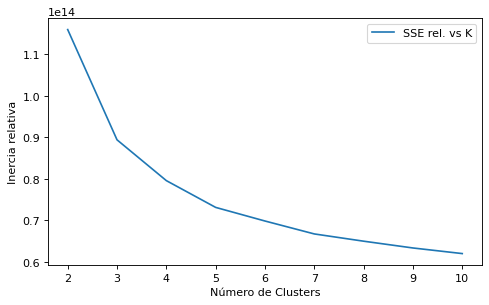

In [311]:
from sklearn.cluster import KMeans
import sklearn.metrics as metrics
# Configuración del modelo de K-Means con un número inicial de clusters (n_clusters) igual a 1
km = KMeans(n_clusters=1, init='k-means++', n_init='auto', max_iter=300, tol=1e-04, random_state=0)
# Ajusta el modelo a los datos estandarizados
km.fit(data_np)
# Calcula la inercia total del modelo con un solo clúster
tss=km.inertia_
# Lista para almacenar las inercias relativas para diferentes números de clusters
distortions = []
# Itera sobre diferentes números de clusters y ajusta el modelo K-Means
for i in range(2, 11):
    km = KMeans(n_clusters=i, init='k-means++', n_init='auto', max_iter=300, tol=1e-04)
    km.fit(data_np)
    #distortions.append(km.inertia_/tss)
    distortions.append(km.inertia_)
    
plt.figure(figsize=(7, 4), dpi=80)
plt.plot(range(2,11), distortions, label="SSE rel. vs K")
plt.xlabel("Número de Clusters")
plt.ylabel("Inercia relativa")
plt.legend(loc='upper right')
plt.show()

Seleccionamos 4 - 5 clusters y vemos cual nos da mejor resultado. 

### 4 clusters

In [312]:
# Clustering
kmeans = KMeans(n_clusters=4)  # Number of clusters is a hyperparameter you can tune
gene_clusters = kmeans.fit_predict(data_np)
# kmeans debería hacerlo con la matriz "normal"? o con la matriz que te da la PCA en 2d? Los clusters salen casi igual.
# también he probado con la matriz sin ordenar y también sale muy parecido. 
# gene_clusters = kmeans.fit_predict(gene_disease_matrix.to_numpy())

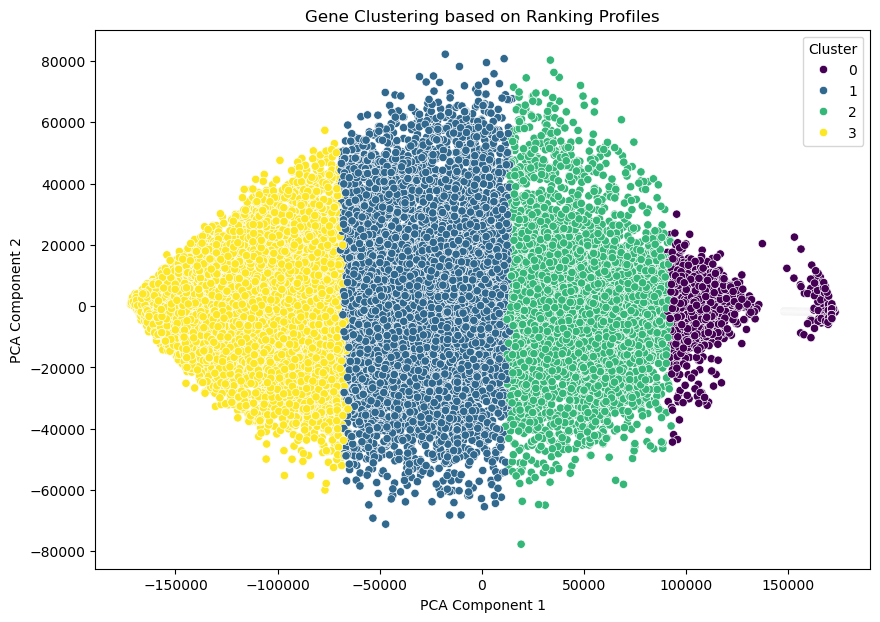

In [313]:
# Visualization
plt.figure(figsize=(10, 7))
fig = sns.scatterplot(x=reduced_matrix[:, 0], y=reduced_matrix[:, 1], hue=gene_clusters, palette='viridis')
plt.title('Gene Clustering based on Ranking Profiles')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
#fig.invert_xaxis() 
#fig.invert_yaxis() 
plt.show()

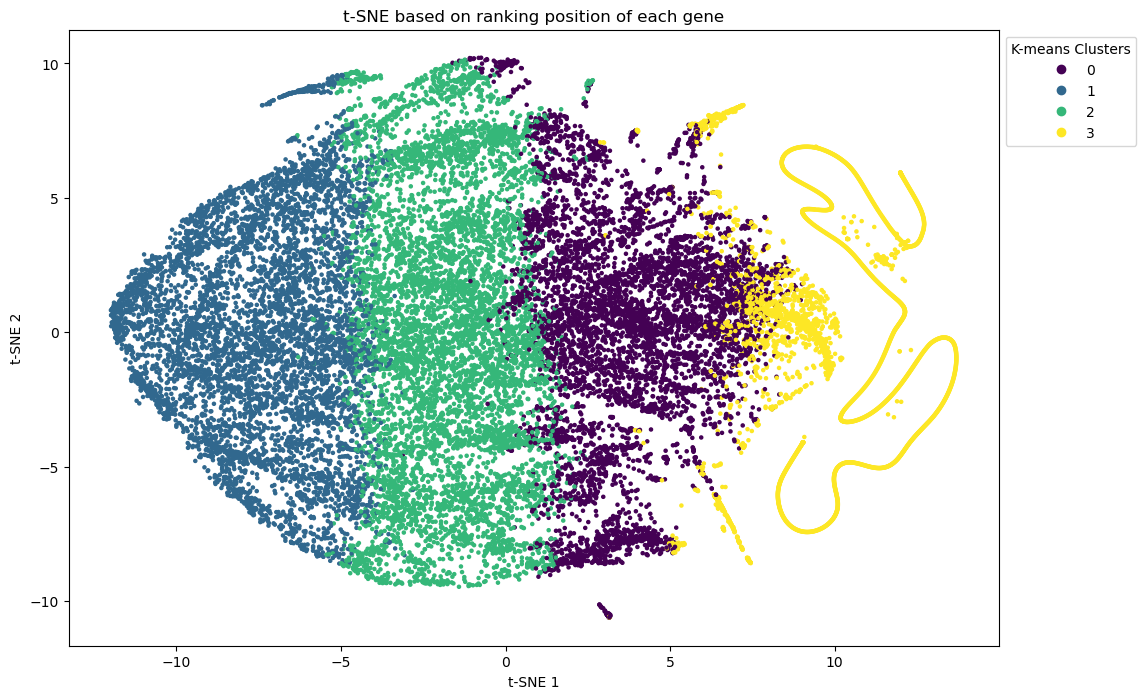

In [18]:
# Plot t-SNE results
plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=gene_clusters, s=5)
plt.legend(handles=scatter.legend_elements()[0], labels=set(gene_clusters), title="K-means Clusters", bbox_to_anchor=(1.0, 1), loc='upper left')
plt.title('t-SNE based on ranking position of each gene')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [21]:
print(Counter(gene_clusters))

Counter({0: 7395, 1: 6469, 2: 6298, 3: 4595})


In [22]:
gene_disease_matrix['Cluster'] = gene_clusters
gene_disease_matrix.head()

/tmp/ipykernel_1421517/2580937037.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  gene_disease_matrix['Cluster'] = gene_clusters


,Adult_solid_tumours_cancer_susceptibility_GA,Childhood_solid_tumours_cancer_susceptibility_GA,Colorectal_cancer_pertinent_cancer_susceptibility_GA,Haematological_malignancies_cancer_susceptibility_GA,Head_and_neck_cancer_pertinent_cancer_susceptibility_GA,Neuroendocrine_cancer_pertinent_cancer_susceptibility_GA,Renal_cancer_pertinent_cancer_susceptibility_GA,Sarcoma_cancer_susceptibility_GA,Sarcoma_susceptibility_GA,Arrhythmogenic_right_ventricular_cardiomyopathy_GA,...,Haematological_malignancies_for_rare_disease_GA,Inherited_ovarian_cancer_(without_breast_cancer)_GA,Inherited_pancreatic_cancer_GA,Inherited_phaeochromocytoma_and_paraganglioma_GA,Inherited_phaeochromocytoma_and_paraganglioma_excluding_NF1_GA,Inherited_predisposition_to_acute_myeloid_leukaemia_(AML)_GA,Inherited_renal_cancer_GA,Multiple_endocrine_tumours_GA,Neurofibromatosis_Type_1_GA,Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
FAAP20,1.0,25.0,5773.0,20.0,4.0,13424.0,5967.0,8414.0,163.0,15627.0,...,13.0,564.0,493.0,13937.0,14695.0,9970.0,11996.0,12204.0,4.0,3
FANCM,2.0,0.0,64.0,0.0,0.0,6109.0,579.0,141.0,21.0,3181.0,...,0.0,20.0,65.0,6115.0,7112.0,316.0,6501.0,3855.0,1.0,2
POT1,3.0,696.0,413.0,12.0,394.0,6885.0,2316.0,485.0,556.0,1846.0,...,11.0,260.0,59.0,10747.0,11748.0,13.0,120.0,4663.0,475.0,2
FAAP100,4.0,4.0,1559.0,1.0,1.0,10504.0,1392.0,3878.0,94.0,13018.0,...,2.0,180.0,176.0,11121.0,13732.0,966.0,10167.0,10262.0,2.0,0
XRCC3,5.0,5.0,107.0,2.0,32.0,2606.0,566.0,90.0,55.0,5914.0,...,3.0,1.0,73.0,1922.0,3057.0,400.0,2021.0,3741.0,11.0,2


In [23]:
cluster = 0
data_np[gene_clusters == cluster].shape

(7395, 209)

In [24]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[10709.72727273  9280.36363636  8677.77511962 ... 11044.57416268
  8094.32535885 10311.88995215]


In [25]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 0: 9374.74
Std del ranking de los genes del cluster 0: 4510.0
Mediana del ranking de los genes del cluster 0: 9902.0
Percentil 20 del ranking de los genes del cluster 0: 4887.0
Percentil 40 del ranking de los genes del cluster 0: 8422.0
Percentil 80 del ranking de los genes del cluster 0: 13682.0


In [26]:
cluster = 3
data_np[gene_clusters == cluster].shape

(4595, 209)

In [27]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[12751.70334928 12275.86124402 13227.30143541 ... 15920.23923445
 14510.8708134  13764.00956938]


In [28]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 3: 13897.99
Std del ranking de los genes del cluster 3: 4600.75
Mediana del ranking de los genes del cluster 3: 15521.0
Percentil 20 del ranking de los genes del cluster 3: 10552.0
Percentil 40 del ranking de los genes del cluster 3: 14503.0
Percentil 80 del ranking de los genes del cluster 3: 17530.0


In [29]:
cluster = 2

In [30]:
data_np[gene_clusters == cluster].shape

(6298, 209)

In [31]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[3911.20574163 6938.99043062 4549.40669856 ... 2147.73205742 3980.49760766
 5540.78947368]


In [32]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 2: 5420.84
Std del ranking de los genes del cluster 2: 3731.96
Mediana del ranking de los genes del cluster 2: 4931.0
Percentil 20 del ranking de los genes del cluster 2: 1753.0
Percentil 40 del ranking de los genes del cluster 2: 3803.0
Percentil 80 del ranking de los genes del cluster 2: 8904.0


In [33]:
cluster = 1
data_np[gene_clusters == cluster].shape

(6469, 209)

In [34]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[16928.25837321 18316.5215311  18023.68421053 ... 20401.55980861
 20401.33014354 20417.11483254]


In [35]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 1: 19743.88
Std del ranking de los genes del cluster 1: 1987.25
Mediana del ranking de los genes del cluster 1: 19651.0
Percentil 20 del ranking de los genes del cluster 1: 19363.0
Percentil 40 del ranking de los genes del cluster 1: 19552.0
Percentil 80 del ranking de los genes del cluster 1: 20923.0


In [36]:
cluster_stats_full = gene_disease_matrix.groupby('Cluster').agg(['mean', 'min', 'max'])
cluster_stats_full.T

Cluster                                                           0  \
Adult_solid_tumours_cancer_susceptibility_GA     mean  10027.678026   
                                                 min       0.000000   
                                                 max   19398.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean  10213.620554   
                                                 min       4.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min       0.000000   
                                                 max   17848.000000   
Neurofibromatosis_Type_1_GA                      mean   9641.530764   
                                                 min       2.000000   
                                                 max   18529.000000   

Cluster                                                           1  \
Adult_solid_tumours_cancer_susceptibility_GA     mean  20258.244706   
                                                 min    1121.000000   
                                                 max   22246.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean  20085.817901   
                                                 min    2278.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min     119.000000   
                                                 max   19737.000000   
Neurofibromatosis_Type_1_GA                      mean  20595.977895   
                                                 min    1910.000000   
                                                 max   22228.000000   

Cluster                                                           2  \
Adult_solid_tumours_cancer_susceptibility_GA     mean   4324.524929   
                                                 min       0.000000   
                                                 max   16487.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean   4726.779771   
                                                 min       0.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min       0.000000   
                                                 max   16432.000000   
Neurofibromatosis_Type_1_GA                      mean   5730.844236   
                                                 min       0.000000   
                                                 max   17614.000000   

Cluster                                                           3  
Adult_solid_tumours_cancer_susceptibility_GA     mean  14939.578890  
                                                 min       0.000000  
                                                 max   21931.000000  
Childhood_solid_tumours_cancer_susceptibility_GA mean  14615.378020  
                                                 min      25.000000  
...                                                             ...  
Multiple_endocrine_tumours_GA                    min      18.000000  
                                                 max   19737.000000  
Neurofibromatosis_Type_1_GA                      mean  13506.514037  
                                                 min       4.000000  
                                                 max   21933.000000  

[627 rows x 4 columns]

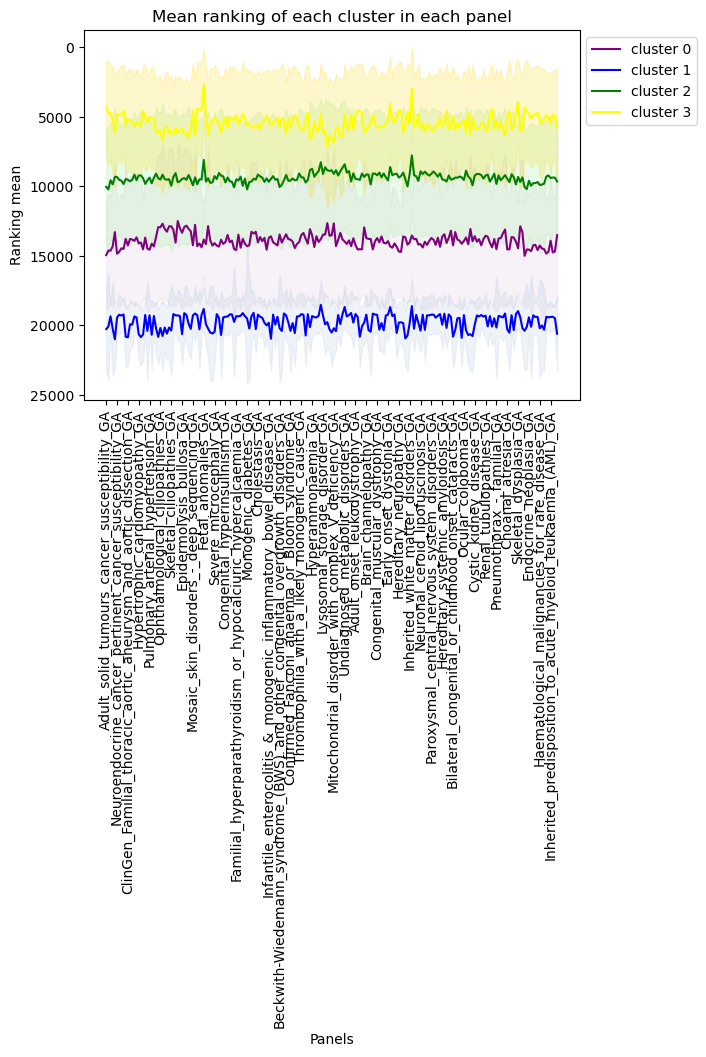

In [33]:
mean_cluster = gene_disease_matrix.groupby('Cluster').agg(['mean'])
max_cluster = gene_disease_matrix.groupby('Cluster').agg(['max'])
min_cluster = gene_disease_matrix.groupby('Cluster').agg(['min'])
std_cluster = gene_disease_matrix.groupby('Cluster').agg(['std'])

fig = plt.subplot()

#plt.errorbar(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[0]), list(std_cluster.iloc[0]), color='thistle', )
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[0]), label='cluster 0', color='purple')
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[1]), label='cluster 1', color='blue' )
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[2]), label='cluster 2', color='green')
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[3]), label='cluster 3', color='yellow' )
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[0])) - np.array(list(std_cluster.iloc[0])), 
                 np.array(list(mean_cluster.iloc[0])) + np.array(list(std_cluster.iloc[0])),
                 color='thistle', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[1])) - np.array(list(std_cluster.iloc[1])), 
                 np.array(list(mean_cluster.iloc[1])) + np.array(list(std_cluster.iloc[1])),
                 color='lightsteelblue', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[2])) - np.array(list(std_cluster.iloc[2])), 
                 np.array(list(mean_cluster.iloc[2])) + np.array(list(std_cluster.iloc[2])),
                 color='lightgreen', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[3])) - np.array(list(std_cluster.iloc[3])), 
                 np.array(list(mean_cluster.iloc[3])) + np.array(list(std_cluster.iloc[3])),
                 color='gold', alpha=0.2)

fig.set_title("Mean ranking of each cluster in each panel")

#plt.xticks([])
plt.xticks(rotation = 90)
plt.xticks(np.take(gene_disease_matrix.columns[:-1], np.arange(0,209,step=5)))
plt.legend(bbox_to_anchor=(1.25, 1.0), loc='upper right')
plt.xlabel("Panels")
plt.ylabel("Ranking mean")
fig.invert_yaxis() 

In [34]:
gene_disease_matrix

,Adult_solid_tumours_cancer_susceptibility_GA,Childhood_solid_tumours_cancer_susceptibility_GA,Colorectal_cancer_pertinent_cancer_susceptibility_GA,Haematological_malignancies_cancer_susceptibility_GA,Head_and_neck_cancer_pertinent_cancer_susceptibility_GA,Neuroendocrine_cancer_pertinent_cancer_susceptibility_GA,Renal_cancer_pertinent_cancer_susceptibility_GA,Sarcoma_cancer_susceptibility_GA,Sarcoma_susceptibility_GA,Arrhythmogenic_right_ventricular_cardiomyopathy_GA,...,Haematological_malignancies_for_rare_disease_GA,Inherited_ovarian_cancer_(without_breast_cancer)_GA,Inherited_pancreatic_cancer_GA,Inherited_phaeochromocytoma_and_paraganglioma_GA,Inherited_phaeochromocytoma_and_paraganglioma_excluding_NF1_GA,Inherited_predisposition_to_acute_myeloid_leukaemia_(AML)_GA,Inherited_renal_cancer_GA,Multiple_endocrine_tumours_GA,Neurofibromatosis_Type_1_GA,Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
FAAP20,1.0,25.0,5773.0,20.0,4.0,13424.0,5967.0,8414.0,163.0,15627.0,...,13.0,564.0,493.0,13937.0,14695.0,9970.0,11996.0,12204.0,4.0,0
FANCM,2.0,0.0,64.0,0.0,0.0,6109.0,579.0,141.0,21.0,3181.0,...,0.0,20.0,65.0,6115.0,7112.0,316.0,6501.0,3855.0,1.0,3
POT1,3.0,696.0,413.0,12.0,394.0,6885.0,2316.0,485.0,556.0,1846.0,...,11.0,260.0,59.0,10747.0,11748.0,13.0,120.0,4663.0,475.0,3
FAAP100,4.0,4.0,1559.0,1.0,1.0,10504.0,1392.0,3878.0,94.0,13018.0,...,2.0,180.0,176.0,11121.0,13732.0,966.0,10167.0,10262.0,2.0,2
XRCC3,5.0,5.0,107.0,2.0,32.0,2606.0,566.0,90.0,55.0,5914.0,...,3.0,1.0,73.0,1922.0,3057.0,400.0,2021.0,3741.0,11.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MTSS1L,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1
C2orf71,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1
FAM57B,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1


### 5 clusters

In [355]:
# Clustering
kmeans = KMeans(n_clusters=5)  # Number of clusters is a hyperparameter you can tune
gene_clusters = kmeans.fit_predict(data_np)
# kmeans debería hacerlo con la matriz "normal"? o con la matriz que te da la PCA en 2d? Los clusters salen casi igual.
# también he probado con la matriz sin ordenar y también sale muy parecido. 
# gene_clusters = kmeans.fit_predict(gene_disease_matrix.to_numpy())

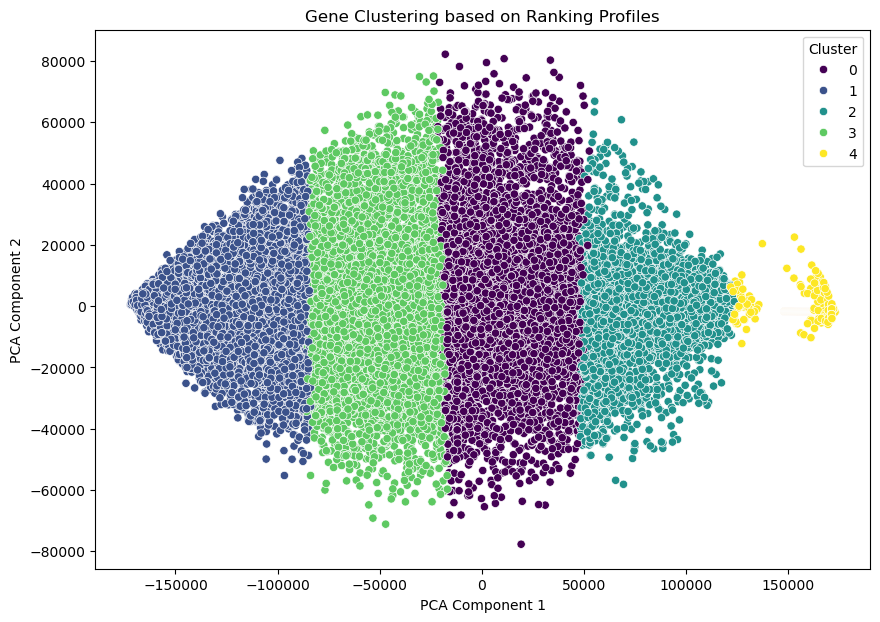

In [356]:
# Visualization
plt.figure(figsize=(10, 7))
fig = sns.scatterplot(x=reduced_matrix[:, 0], y=reduced_matrix[:, 1], hue=gene_clusters, palette='viridis')
plt.title('Gene Clustering based on Ranking Profiles')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
#fig.invert_xaxis() 
#fig.invert_yaxis() 
plt.show()

In [316]:
tsne_results
tsne = pd.DataFrame(tsne_results)
#tsne.to_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/analysis/data_exploration/tsne.tsv', sep="\t")

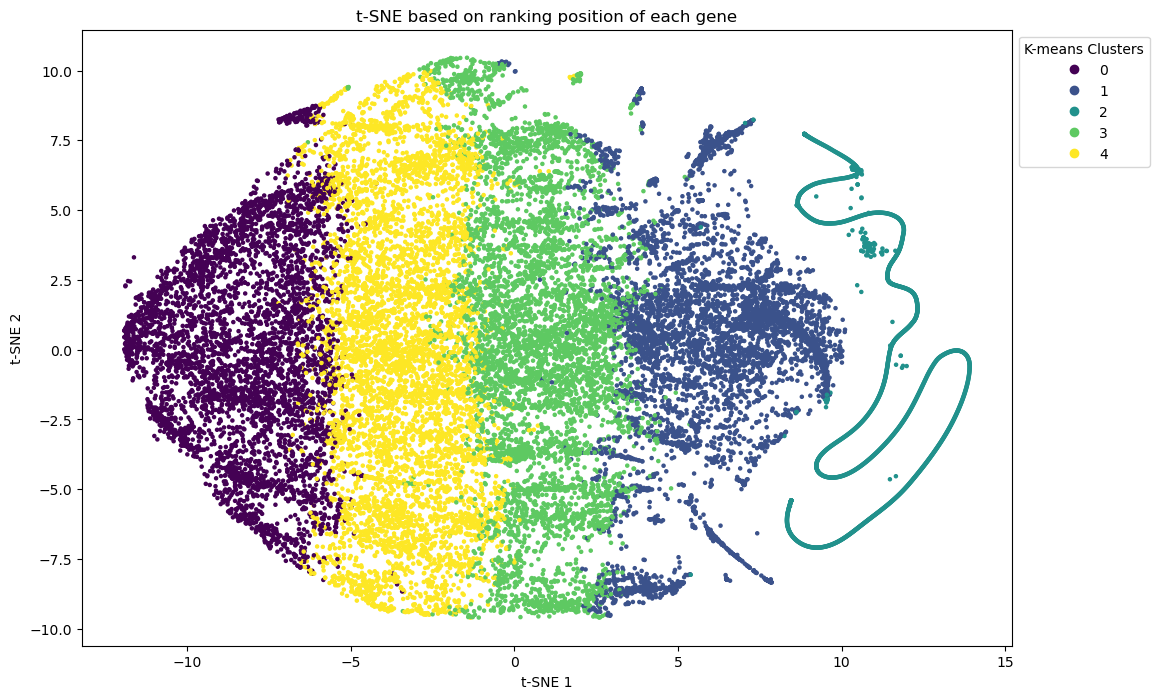

In [317]:
# Plot t-SNE results
plt.figure(figsize=(12, 8))
scatter = plt.scatter(tsne_results[:, 0], tsne_results[:, 1], c=gene_clusters, s=5)
plt.title('t-SNE based on ranking position of each gene')
plt.legend(handles=scatter.legend_elements()[0], labels=set(gene_clusters), title="K-means Clusters", bbox_to_anchor=(1.0, 1), loc='upper left')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

In [318]:
print(Counter(gene_clusters))

Counter({1: 5952, 4: 5845, 3: 5740, 0: 4785, 2: 1892})


In [357]:
gene_disease_matrix['Cluster'] = gene_clusters
gene_disease_matrix.head()

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA",Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,308.0,...,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0,1
MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,224.0,...,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0,1
DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,79.0,...,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0,1
ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,144.0,...,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0,1
TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,189.0,...,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0,1


In [320]:
cluster = 1
data_np[gene_clusters == cluster].shape

(5952, 209)

In [321]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[15960.02392344 16514.6507177  15330.75119617 ... 18824.82296651
 16631.08133971 19688.54066986]


In [192]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 1: 23101.9
Std del ranking de los genes del cluster 1: 1093.33
Mediana del ranking de los genes del cluster 1: 23186.0
Percentil 20 del ranking de los genes del cluster 1: 22613.0
Percentil 40 del ranking de los genes del cluster 1: 22995.0
Percentil 80 del ranking de los genes del cluster 1: 23764.0


In [193]:
cluster = 4
data_np[gene_clusters == cluster].shape

(5737, 208)

In [194]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[11799.59134615 10915.10576923 11416.09615385 ... 11364.09134615
 12674.26442308 11654.83173077]


In [195]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 4: 12891.32
Std del ranking de los genes del cluster 4: 4584.11
Mediana del ranking de los genes del cluster 4: 13121.0
Percentil 20 del ranking de los genes del cluster 4: 8962.0
Percentil 40 del ranking de los genes del cluster 4: 11905.0
Percentil 80 del ranking de los genes del cluster 4: 16818.0


In [196]:
cluster = 3
data_np[gene_clusters == cluster].shape

(5855, 208)

In [197]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[ 6911.25480769 10474.07211538  6916.26923077 ...  6934.35576923
  7683.76442308  7189.98557692]


In [198]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 3: 8429.12
Std del ranking de los genes del cluster 3: 4413.96
Mediana del ranking de los genes del cluster 3: 8101.0
Percentil 20 del ranking de los genes del cluster 3: 4459.0
Percentil 40 del ranking de los genes del cluster 3: 6951.0
Percentil 80 del ranking de los genes del cluster 3: 12113.0


In [199]:
cluster = 0
data_np[gene_clusters == cluster].shape

(4784, 208)

In [200]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[2146.80769231 4152.95192308  673.14903846 ... 1069.63942308 1159.47596154
  527.55288462]


In [201]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 0: 3860.24
Std del ranking de los genes del cluster 0: 3249.91
Mediana del ranking de los genes del cluster 0: 3094.0
Percentil 20 del ranking de los genes del cluster 0: 1039.0
Percentil 40 del ranking de los genes del cluster 0: 2340.0
Percentil 80 del ranking de los genes del cluster 0: 6286.0


In [59]:
cluster = 2
data_np[gene_clusters == cluster].shape

(3402, 209)

In [60]:
print("Media del ranking por gen en el cluster 0")
print(data_np[gene_clusters == cluster].mean(axis = 1)) # media por gen

Media del ranking por gen en el cluster 0
[13227.30143541 16928.25837321 15674.36363636 ... 14510.8708134
 17138.30143541 13764.00956938]


In [61]:
print("Media del ranking de los genes del cluster " + str(cluster) + ": "  + str(round(data_np[gene_clusters == cluster].mean(),2))) # media del cluster
print("Std del ranking de los genes del cluster " + str(cluster) + ": " + str(round(data_np[gene_clusters == cluster].std(),2)))
print("Mediana del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.median(data_np[gene_clusters == cluster]), 2)))

print("Percentil 20 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 20),2)))
print("Percentil 40 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 40),2)))
print("Percentil 80 del ranking de los genes del cluster " + str(cluster) + ": " + str(round(np.percentile(data_np[gene_clusters == cluster], 80),2)))

Media del ranking de los genes del cluster 2: 14953.48
Std del ranking de los genes del cluster 2: 4385.09
Mediana del ranking de los genes del cluster 2: 16583.0
Percentil 20 del ranking de los genes del cluster 2: 12578.0
Percentil 40 del ranking de los genes del cluster 2: 15836.0
Percentil 80 del ranking de los genes del cluster 2: 18074.0


In [65]:
cluster_stats_full = gene_disease_matrix.groupby('Cluster').agg(['mean', 'min', 'max'])
cluster_stats_full.T

Cluster                                                           0  \
Adult_solid_tumours_cancer_susceptibility_GA     mean  12022.876407   
                                                 min       0.000000   
                                                 max   19565.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean  11936.071789   
                                                 min       4.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min       0.000000   
                                                 max   18437.000000   
Neurofibromatosis_Type_1_GA                      mean  11066.808886   
                                                 min       2.000000   
                                                 max   19044.000000   

Cluster                                                           1  \
Adult_solid_tumours_cancer_susceptibility_GA     mean  20383.245151   
                                                 min    3020.000000   
                                                 max   22246.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean  20217.898778   
                                                 min    2278.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min     418.000000   
                                                 max   19737.000000   
Neurofibromatosis_Type_1_GA                      mean  20773.675795   
                                                 min    1910.000000   
                                                 max   22228.000000   

Cluster                                                           2  \
Adult_solid_tumours_cancer_susceptibility_GA     mean  15824.530276   
                                                 min       0.000000   
                                                 max   22116.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean  15487.753968   
                                                 min     255.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min      22.000000   
                                                 max   19737.000000   
Neurofibromatosis_Type_1_GA                      mean  14475.225162   
                                                 min     206.000000   
                                                 max   21933.000000   

Cluster                                                           3  \
Adult_solid_tumours_cancer_susceptibility_GA     mean   7943.618257   
                                                 min       0.000000   
                                                 max   18244.000000   
Childhood_solid_tumours_cancer_susceptibility_GA mean   8389.120000   
                                                 min       0.000000   
...                                                             ...   
Multiple_endocrine_tumours_GA                    min       0.000000   
                                                 max   17431.000000   
Neurofibromatosis_Type_1_GA                      mean   8257.026888   
                                                 min       0.000000   
                                                 max   18101.000000   

Cluster                                                           4  
Adult_solid_tumours_cancer_susceptibility_GA     mean   3062.613462  
                                                 min       0.000000  
                                                 max   14262.000000  
Childhood_solid_tumours_cancer_susceptibility_GA mean   3366.169512  
                                                 min       0.000000  
...                                                             ...  
Multiple_endocrine_tumours_GA                    min       0.000000  
                            

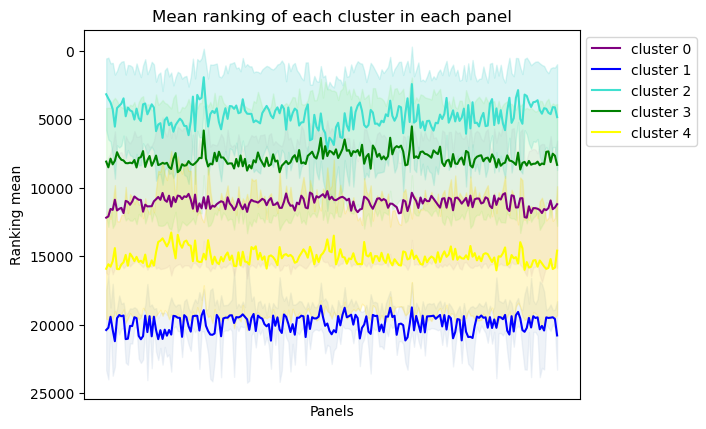

In [57]:
mean_cluster = gene_disease_matrix.groupby('Cluster').agg(['mean'])
max_cluster = gene_disease_matrix.groupby('Cluster').agg(['max'])
min_cluster = gene_disease_matrix.groupby('Cluster').agg(['min'])
std_cluster = gene_disease_matrix.groupby('Cluster').agg(['std'])
sem_cluster = gene_disease_matrix.groupby('Cluster').agg(['sem'])

fig = plt.subplot()

#plt.errorbar(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[0]), list(std_cluster.iloc[0]), color='thistle', )
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[0]), label='cluster 0', color='purple')
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[1]), label='cluster 1', color='blue' )
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[2]), label='cluster 2', color='turquoise')
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[3]), label='cluster 3', color='green' )
plt.plot(list(gene_disease_matrix.columns[:-1]), list(mean_cluster.iloc[4]), label='cluster 4', color='yellow' )

plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[0])) - np.array(list(std_cluster.iloc[0])), 
                 np.array(list(mean_cluster.iloc[0])) + np.array(list(std_cluster.iloc[0])),
                 color='thistle', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[1])) - np.array(list(std_cluster.iloc[1])), 
                 np.array(list(mean_cluster.iloc[1])) + np.array(list(std_cluster.iloc[1])),
                 color='lightsteelblue', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[2])) - np.array(list(std_cluster.iloc[2])), 
                 np.array(list(mean_cluster.iloc[2])) + np.array(list(std_cluster.iloc[2])),
                 color='mediumturquoise', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[3])) - np.array(list(std_cluster.iloc[3])), 
                 np.array(list(mean_cluster.iloc[3])) + np.array(list(std_cluster.iloc[3])),
                 color='lightgreen', alpha=0.2)
plt.fill_between(list(gene_disease_matrix.columns[:-1]), np.array(list(mean_cluster.iloc[4])) - np.array(list(std_cluster.iloc[4])), 
                 np.array(list(mean_cluster.iloc[4])) + np.array(list(std_cluster.iloc[4])),
                 color='gold', alpha=0.2)

fig.set_title("Mean ranking of each cluster in each panel")

plt.xticks([])
#plt.xticks(rotation = 90)
#plt.xticks(np.take(gene_disease_matrix.columns[:-1], np.arange(0,211,step=5)))
plt.legend(bbox_to_anchor=(1.25, 1.0), loc='upper right')
plt.xlabel("Panels")
plt.ylabel("Ranking mean")
fig.invert_yaxis() 

In [58]:
gene_disease_matrix

,Adult_solid_tumours_cancer_susceptibility_GA,Childhood_solid_tumours_cancer_susceptibility_GA,Colorectal_cancer_pertinent_cancer_susceptibility_GA,Haematological_malignancies_cancer_susceptibility_GA,Head_and_neck_cancer_pertinent_cancer_susceptibility_GA,Neuroendocrine_cancer_pertinent_cancer_susceptibility_GA,Renal_cancer_pertinent_cancer_susceptibility_GA,Sarcoma_cancer_susceptibility_GA,Sarcoma_susceptibility_GA,Arrhythmogenic_right_ventricular_cardiomyopathy_GA,...,Haematological_malignancies_for_rare_disease_GA,Inherited_ovarian_cancer_(without_breast_cancer)_GA,Inherited_pancreatic_cancer_GA,Inherited_phaeochromocytoma_and_paraganglioma_GA,Inherited_phaeochromocytoma_and_paraganglioma_excluding_NF1_GA,Inherited_predisposition_to_acute_myeloid_leukaemia_(AML)_GA,Inherited_renal_cancer_GA,Multiple_endocrine_tumours_GA,Neurofibromatosis_Type_1_GA,Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
FAAP20,1.0,25.0,5773.0,20.0,4.0,13424.0,5967.0,8414.0,163.0,15627.0,...,13.0,564.0,493.0,13937.0,14695.0,9970.0,11996.0,12204.0,4.0,0
FANCM,2.0,0.0,64.0,0.0,0.0,6109.0,579.0,141.0,21.0,3181.0,...,0.0,20.0,65.0,6115.0,7112.0,316.0,6501.0,3855.0,1.0,2
POT1,3.0,696.0,413.0,12.0,394.0,6885.0,2316.0,485.0,556.0,1846.0,...,11.0,260.0,59.0,10747.0,11748.0,13.0,120.0,4663.0,475.0,3
FAAP100,4.0,4.0,1559.0,1.0,1.0,10504.0,1392.0,3878.0,94.0,13018.0,...,2.0,180.0,176.0,11121.0,13732.0,966.0,10167.0,10262.0,2.0,0
XRCC3,5.0,5.0,107.0,2.0,32.0,2606.0,566.0,90.0,55.0,5914.0,...,3.0,1.0,73.0,1922.0,3057.0,400.0,2021.0,3741.0,11.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MTSS1L,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1
C2orf71,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1
FAM57B,22246.0,22674.0,19557.0,22664.0,22726.0,19661.0,19570.0,19544.0,19526.0,22270.0,...,22740.0,22256.0,22256.0,19579.0,19655.0,19688.0,19573.0,19737.0,22228.0,1


In [359]:
#gene_disease_matrix.to_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/revision/ToppGenes_clustered_no_NA.tsv', sep="\t")

## Con 7 clusters

In [322]:
# Clustering
kmeans = KMeans(n_clusters=7)  # Number of clusters is a hyperparameter you can tune
gene_clusters = kmeans.fit_predict(data_np)
# kmeans debería hacerlo con la matriz "normal"? o con la matriz que te da la PCA en 2d? Los clusters salen casi igual.
# también he probado con la matriz sin ordenar y también sale muy parecido. 
# gene_clusters = kmeans.fit_predict(gene_disease_matrix.to_numpy())

print(Counter(gene_clusters))



Counter({2: 4687, 3: 4367, 5: 4147, 1: 3639, 4: 3329, 6: 2193, 0: 1852})


In [323]:
gene_disease_matrix['Cluster'] = gene_clusters
gene_disease_matrix.head()


#gene_disease_matrix.to_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/analysis/data_exploration/glow_matrix_clustered_no_NA_7_clusters.tsv', sep="\t")

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA",Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,308.0,...,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0,4
MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,224.0,...,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0,4
DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,79.0,...,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0,4
ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,144.0,...,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0,4
TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,189.0,...,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0,4


# Stats

## %Top

Consideramos que el top es el 5% de las primeras posiciones. Si hay 20000 posiciones, serán en la posición 1000. No vamos a tener en cuenta los ceros (las veces que el gen es input). 

In [360]:
threshold_top=0.05

In [361]:
gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].max(axis=0)

Distal_myopathies_GA                                                                 24081.0
Ductal_plate_malformation_GA                                                         24084.0
Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA    24085.0
Early_onset_dystonia_GA                                                              24043.0
Early_onset_or_syndromic_epilepsy_GA                                                 23372.0
                                                                                      ...   
VACTERL-like_phenotypes_GA                                                           24084.0
Vascular_skin_disorders_GA                                                           24080.0
Vici_Syndrome_and_other_autophagy_disorders_GA                                       24092.0
White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA                  23906.0
Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA    

In [362]:
max_valuedisease=gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].max(axis=0)
division = [x*threshold_top for x in list(max_valuedisease)] 

In [363]:
max_valuedisease = pd.DataFrame(max_valuedisease)
max_valuedisease["top_ranking"] = division

In [364]:
max_valuedisease.T.iloc[1:]

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
top_ranking,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4


In [365]:
comparison_df = pd.DataFrame([division] * gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].shape[0], columns=max_valuedisease.index)
comparison_df.index = gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].index
comparison_df # creamos este dataframe con el valor máximo del %top. Ahora compararemos nuestra tabla con esta (¿la posición 0,0 de glowmatrix es menor que la posición 0.0 de comparation_df?). Así calculamos el % de top. 

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
MYBPC3,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
DMD,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
ACTN2,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
TNNT2,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C7orf43,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
NEPRO,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4
TMEM251,1204.05,1204.2,1204.25,1202.15,1168.6,1202.65,1204.15,1202.35,1204.45,1203.4,...,1204.2,1204.0,1172.4,1200.85,1192.55,1204.2,1204.0,1204.6,1195.3,1204.4


In [366]:
gene_disease_matrix.head()

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA",Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,1.0,5219.0,2739.0,2605.0,1048.0,2028.0,2421.0,311.0,2411.0,308.0,...,6246.0,1601.0,1011.0,3031.0,1366.0,471.0,986.0,1706.0,2950.0,1
MYBPC3,2.0,8346.0,4287.0,7394.0,1978.0,1367.0,10017.0,918.0,4019.0,224.0,...,9816.0,4579.0,2343.0,3219.0,2917.0,3589.0,484.0,3586.0,8374.0,1
DMD,3.0,637.0,46.0,98.0,296.0,302.0,504.0,97.0,2176.0,79.0,...,1670.0,1500.0,41.0,72.0,1492.0,1863.0,42.0,728.0,1475.0,1
ACTN2,4.0,1773.0,342.0,3115.0,157.0,455.0,1806.0,243.0,3488.0,144.0,...,2937.0,2446.0,206.0,58.0,2086.0,1778.0,2002.0,3261.0,8694.0,1
TNNT2,5.0,3129.0,1641.0,4903.0,1081.0,516.0,5617.0,1534.0,2243.0,189.0,...,900.0,2278.0,1605.0,2639.0,1474.0,1037.0,4320.0,2668.0,6427.0,1


In [367]:
gene_disease_matrix.tail()

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA",Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,
C7orf43,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0,4
NEPRO,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0,4
TMEM251,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0,4
WISP3,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,24088.0,4
TARS,24081.0,24084.0,24085.0,24043.0,23372.0,24053.0,24083.0,24047.0,24089.0,24068.0,...,24080.0,23448.0,24017.0,23851.0,24084.0,24080.0,24092.0,23906.0,0.0,4


In [368]:
gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"] != 0

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
MYBPC3,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
DMD,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
ACTN2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TNNT2,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C7orf43,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
NEPRO,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
TMEM251,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True


In [369]:
# Create a boolean mask where True indicates the element in df is less than the element in comparison_list
mask = (gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"] < comparison_df) & (gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"] != 0)

In [370]:
mask # True significa que ese gen, en ese panel, está en una posición top (menor al threshold que hayamos puesto). 

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Thrombophilia_with_a_likely_monogenic_cause_GA,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA"
SYMBOL,,,,,,,,,,,,,,,,,,,,,
MYH6,True,False,False,False,True,False,False,True,False,True,...,False,False,False,True,False,False,True,True,False,False
MYBPC3,True,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
DMD,True,True,True,True,True,True,True,True,False,True,...,True,False,False,True,True,False,False,True,True,False
ACTN2,True,False,True,False,True,True,False,True,False,True,...,True,False,False,True,True,False,False,False,False,False
TNNT2,True,False,False,False,True,True,False,False,False,True,...,False,True,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C7orf43,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
NEPRO,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
TMEM251,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [371]:
n_tops = mask.sum(axis = 1)
n_tops

SYMBOL
MYH6        74
MYBPC3      31
DMD        158
ACTN2       98
TNNT2       57
          ... 
C7orf43      0
NEPRO        0
TMEM251      0
WISP3        0
TARS         0
Length: 24214, dtype: int64

In [372]:
n_panels = (gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"] != 0).sum(axis = 1)
n_panels # número de paneles en los que el gen no es 0 (no es input). 

SYMBOL
MYH6       204
MYBPC3     203
DMD        199
ACTN2      203
TNNT2      205
          ... 
C7orf43    208
NEPRO      208
TMEM251    208
WISP3      208
TARS       208
Length: 24214, dtype: int64

In [373]:
stat_tops = pd.DataFrame(n_tops)
stat_tops.columns = ["N_panels_top"]
stat_tops["N_panels_nozero"] = n_panels

stat_tops["Porc_panels_top"] = stat_tops["N_panels_top"]/stat_tops["N_panels_nozero"]

In [374]:
stat_tops

,N_panels_top,N_panels_nozero,Porc_panels_top
SYMBOL,,,
MYH6,74,204,0.362745
MYBPC3,31,203,0.152709
DMD,158,199,0.793970
ACTN2,98,203,0.482759
TNNT2,57,205,0.278049
...,...,...,...
C7orf43,0,208,0.000000
NEPRO,0,208,0.000000
TMEM251,0,208,0.000000


Sacamos otras medidas interesantes

In [375]:
stat_tops["std"] = gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].std(axis = 1)

In [376]:
np.array(gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"]).std(axis = 1)

array([2087.72397252, 3111.66136334,  790.20392653, ..., 1667.54159141,
       1667.54159141, 1667.57732866])

In [377]:
import numpy.ma as ma

mx = ma.masked_array(data_np, mask=data_np==0)
std_no_cero = pd.DataFrame(mx).std(axis=1)

In [378]:
stat_tops["std_no_0"] = list(std_no_cero)

In [379]:
stat_tops

,N_panels_top,N_panels_nozero,Porc_panels_top,std,std_no_0
SYMBOL,,,,,
MYH6,74,204,0.362745,2092.736522,2090.839673
MYBPC3,31,203,0.152709,3119.132350,3081.062263
DMD,158,199,0.793970,792.101178,796.824470
ACTN2,98,203,0.482759,1922.483519,1923.973168
TNNT2,57,205,0.278049,2057.437671,2046.156793
...,...,...,...,...,...
C7orf43,0,208,0.000000,1671.628945,184.388787
NEPRO,0,208,0.000000,1671.545298,182.961870
TMEM251,0,208,0.000000,1671.545298,182.961870


In [380]:
print(gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].head())

        Distal_myopathies_GA  Ductal_plate_malformation_GA  \
SYMBOL                                                       
MYH6                     1.0                        5219.0   
MYBPC3                   2.0                        8346.0   
DMD                      3.0                         637.0   
ACTN2                    4.0                        1773.0   
TNNT2                    5.0                        3129.0   

        Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA  \
SYMBOL                                                                                      
MYH6                                               2739.0                                   
MYBPC3                                             4287.0                                   
DMD                                                  46.0                                   
ACTN2                                               342.0                                   
TNNT2  

In [381]:
gene_disease_matrix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24214 entries, MYH6 to TARS
Columns: 210 entries, Distal_myopathies_GA to Cluster
dtypes: float64(209), int32(1)
memory usage: 39.4+ MB


In [382]:
gene_disease_matrix[gene_disease_matrix.isna().any(axis=1)]

,Distal_myopathies_GA,Ductal_plate_malformation_GA,Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA,Early_onset_dystonia_GA,Early_onset_or_syndromic_epilepsy_GA,Ectodermal_dysplasia_GA,Ectodermal_dysplasia_without_a_known_gene_mutation_GA,Ehlers_Danlos_syndrome_with_a_likely_monogenic_cause_GA,Endocrine_neoplasia_GA,Epidermolysis_bullosa_and_congenital_skin_fragility_GA,...,Tubulointerstitial_kidney_disease_GA,Undiagnosed_metabolic_disorders_GA,Unexplained_kidney_failure_in_young_people_GA,Unexplained_young_onset_end-stage_renal_disease_GA,VACTERL-like_phenotypes_GA,Vascular_skin_disorders_GA,Vici_Syndrome_and_other_autophagy_disorders_GA,White_matter_disorders_and_cerebral_calcification_-_narrow_panel_GA,"Xeroderma_pigmentosum,_Trichothiodystrophy_or_Cockayne_syndrome_GA",Cluster
SYMBOL,,,,,,,,,,,,,,,,,,,,,


In [383]:
stat_tops["median"] = gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"].median(axis = 1)
median_no_cero=pd.DataFrame(mx).median(axis=1)
stat_tops["median_no_0"] = list(median_no_cero)

In [384]:
stat_tops

,N_panels_top,N_panels_nozero,Porc_panels_top,std,std_no_0,median,median_no_0
SYMBOL,,,,,,,
MYH6,74,204,0.362745,2092.736522,2090.839673,1740.0,1787.0
MYBPC3,31,203,0.152709,3119.132350,3081.062263,3813.0,3920.0
DMD,158,199,0.793970,792.101178,796.824470,383.0,427.0
ACTN2,98,203,0.482759,1922.483519,1923.973168,1217.0,1418.0
TNNT2,57,205,0.278049,2057.437671,2046.156793,2316.0,2328.0
...,...,...,...,...,...,...,...
C7orf43,0,208,0.000000,1671.628945,184.388787,24067.0,24067.5
NEPRO,0,208,0.000000,1671.545298,182.961870,24067.0,24067.5
TMEM251,0,208,0.000000,1671.545298,182.961870,24067.0,24067.5


In [385]:
stat_tops["cluster"] = gene_disease_matrix.loc[:, "Cluster"]

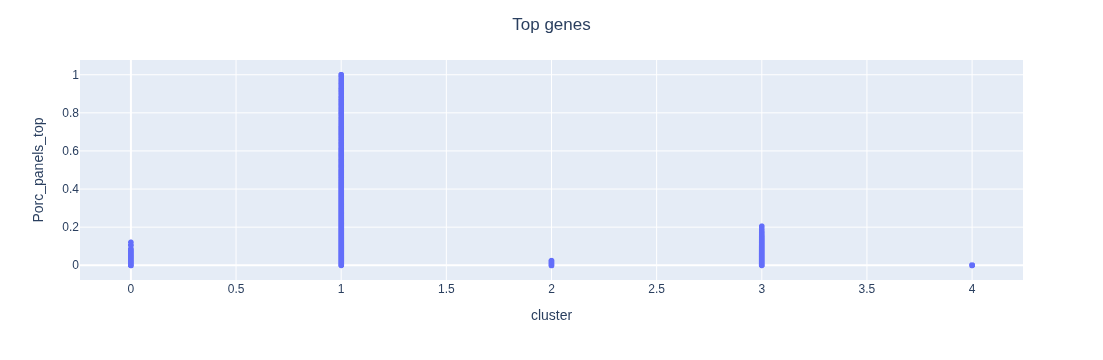

In [386]:
import plotly.express as px
import pandas as pd

stat_tops["Symbol"] = stat_tops.index

fig = px.scatter(stat_tops, x="cluster", y="Porc_panels_top", log_x=False, size_max=100, 
                 hover_data={'Symbol':True
                            })
fig.update_layout(title_text='Top genes', title_x=0.5)
fig.show()

In [387]:
stat_tops["panel_0"] = (gene_disease_matrix.loc[:, gene_disease_matrix.columns != "Cluster"] == 0).sum(axis = 1)

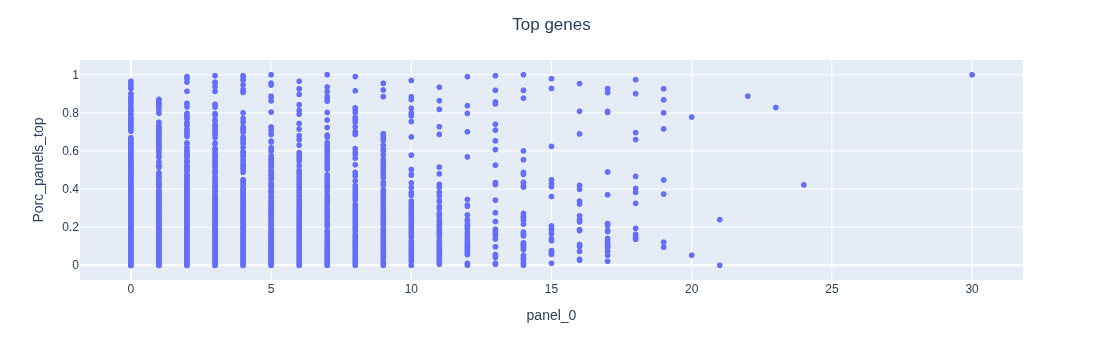

In [388]:
import plotly.express as px
import pandas as pd

stat_tops["Symbol"] = stat_tops.index

fig = px.scatter(stat_tops, x="panel_0", y="Porc_panels_top", log_x=False, size_max=100, 
                 hover_data={'Symbol':True
                            })
fig.update_layout(title_text='Top genes', title_x=0.5)
fig.show()

In [389]:
stat_tops[stat_tops["Porc_panels_top"] >= 0.3]

,N_panels_top,N_panels_nozero,Porc_panels_top,std,std_no_0,median,median_no_0,cluster,Symbol,panel_0
SYMBOL,,,,,,,,,,
MYH6,74,204,0.362745,2092.736522,2090.839673,1740.0,1787.0,1,MYH6,5
DMD,158,199,0.793970,792.101178,796.824470,383.0,427.0,1,DMD,10
ACTN2,98,203,0.482759,1922.483519,1923.973168,1217.0,1418.0,1,ACTN2,6
TPM1,65,205,0.317073,1839.606757,1831.929654,1790.0,1840.0,1,TPM1,4
MYH11,65,204,0.318627,1742.886203,1733.027215,1788.0,1839.5,1,MYH11,5
...,...,...,...,...,...,...,...,...,...,...
DNM2,159,199,0.798995,765.526071,771.205162,340.0,374.0,1,DNM2,10
HSPB1,135,205,0.658537,1333.579522,1335.844085,767.0,782.0,1,HSPB1,4
SQSTM1,138,201,0.686567,1080.172738,1079.920074,733.0,800.0,1,SQSTM1,8


In [390]:
#stat_tops.to_csv('/home/yolanda/tblab/yolanda/GLOWgenes/panelAPP/revision/ToppGene_stat_tops_vfinal.tsv', sep="\t")

In [150]:
stat_tops.sort_values("Porc_panels_top", ascending=False)

,N_panels_top,N_panels_nozero,Porc_panels_top,std,std_no_0,median,median_no_0,cluster,Symbol,panel_0
SYMBOL,,,,,,,,,,
PTEN,178,178,1.000000,171.292073,165.795688,152.0,174.0,3,PTEN,30
CTNNB1,203,203,1.000000,140.656382,141.606931,34.0,36.0,3,CTNNB1,5
TP53,194,194,1.000000,149.596512,151.412999,69.5,77.5,3,TP53,14
MTOR,201,201,1.000000,197.013472,197.844280,107.0,114.0,3,MTOR,7
AKT1,204,205,0.995122,178.791507,179.291349,81.0,81.0,3,AKT1,3
...,...,...,...,...,...,...,...,...,...,...
MIR301B,0,208,0.000000,3146.341004,3146.341004,16739.0,16739.0,1,MIR301B,0
EEF1G,0,208,0.000000,3436.919814,3436.919814,12207.0,12207.0,4,EEF1G,0
HNRNPF,0,208,0.000000,3769.862281,3769.862281,10508.0,10508.0,0,HNRNPF,0


In [154]:
stat_tops[stat_tops["Symbol"] == "FAM181B"]

,N_panels_top,N_panels_nozero,Porc_panels_top,std,std_no_0,median,median_no_0,cluster,Symbol,panel_0
SYMBOL,,,,,,,,,,
FAM181B,0,208,0.0,1912.912555,1912.912555,21512.5,21512.5,2,FAM181B,0


In [274]:
print(gene_disease_matrix.tail())

        Distal_myopathies_GA  Ductal_plate_malformation_GA  \
SYMBOL                                                       
SMPX                     0.0                       11808.0   
SQSTM1                   0.0                        1709.0   
TIA1                     0.0                        4085.0   
TTN                      0.0                        1556.0   
VCP                      0.0                          63.0   

        Early_onset_dementia_(encompassing_fronto-temporal_dementia_and_prion_disease)_GA  \
SYMBOL                                                                                      
SMPX                                              11464.0                                   
SQSTM1                                               53.0                                   
TIA1                                               4734.0                                   
TTN                                                 897.0                                   
VCP    

In [278]:
df_numeric = gene_disease_matrix.drop(columns=["Cluster"])

min_per_gene = df_numeric.replace(0, np.nan).min(axis=1)

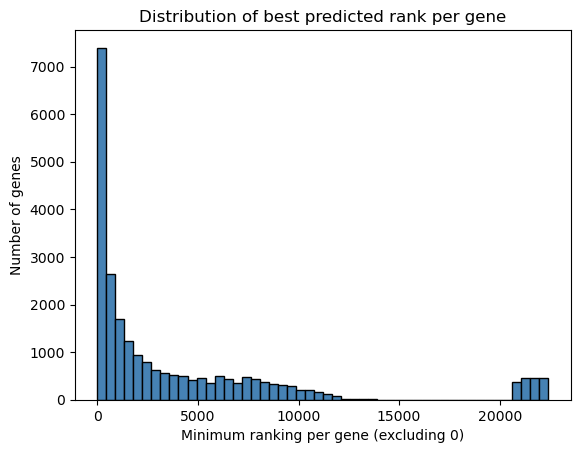

In [279]:
import matplotlib.pyplot as plt

plt.hist(min_per_gene.dropna(), bins=50, color="steelblue", edgecolor="black")
plt.xlabel("Minimum ranking per gene (excluding 0)")
plt.ylabel("Number of genes")
plt.title("Distribution of best predicted rank per gene")
plt.show()

Series([], Name: count, dtype: int64)

Series([], Name: count, dtype: int64)